In [1]:
import datetime
import itertools
import json
import os
import pathlib

import IPython.display
import matplotlib
import matplotlib.markers
import matplotlib.pyplot
import matplotlib.style
import matplotlib.ticker
import matplotlib.transforms
import numpy
import pandas
import swifter

from utils import taxonomy


JSON2CBOR_EVAL_DIR = pathlib.Path.cwd() / "03_json2cbor_eval"
os.environ["JSON2CBOR_EVAL_DIR"] = str(JSON2CBOR_EVAL_DIR)

OUTPUT_PATH = pathlib.Path(JSON2CBOR_EVAL_DIR) / "plots"
if not OUTPUT_PATH.exists():
    OUTPUT_PATH.mkdir()


def cdf(values, bin_size=0.01):
    bins = numpy.arange(values.min(), values.max(), bin_size)
    hist, x = numpy.histogram(values, bins=bins, density=1)
    if len(x) < 2:
        return numpy.array([]), numpy.array([])
    dx = x[1] - x[0]
    return x[1:], (numpy.cumsum(hist) * dx)


def plot_cdf(axs, df, label, style={}, bin_size=0.01):
    x, y = cdf(df, bin_size=bin_size)
    for ax in axs:
        ax.plot(x, y, label=label, **style)

# Evaluating the Use of CBOR for Object Encoding
## Method

We summarize our method in the figure below (Figure 3 in the paper).
We first scrape GitHub for JSON files (left-hand side) which we store in the file system and then use those JSONs to convert them to CBOR on a Raspberry Pi (right-hand side).
During conversion the taxonomy is determined according to the method proposed by Viotti and Kinderkhedia in their work “[A Benchmark of JSON-compatible Binary Serialization Specifications Technical Report](https://arxiv.org/abs/2201.03051)”.

In [2]:
%load_ext jupyter_tikz

preamble = r"""
\usepackage{adjustbox}
\usepackage{fontawesome5}
\usepackage[T1]{fontenc}
\usepackage[tt=false, type1=true]{libertine}
\usepackage[varqu]{zi4}
\usepackage[libertine]{newtxmath}
\usepackage{tikz}

\usetikzlibrary{
  calc,
  colorbrewer,
  fit,
  positioning
}
\pgfdeclarelayer{bg}
\pgfdeclarelayer{fg}
\pgfsetlayers{bg,main,fg}
"""

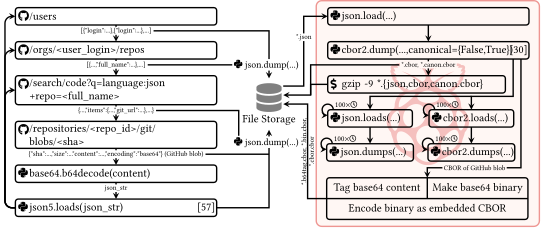

In [3]:
%%tikz -p "$preamble" -S "03_json2cbor_eval/figs/json-collect"
\adjustbox{scale=1.4}{\input{03_json2cbor_eval/figs/json-collect.tex}}

## Dataset Collection

Due to the rate-limiting imposed by GitHub and our method of doing the conversion to CBOR on a Raspberry Pi to achieve reproducible runtimes, the dataset collection can take several weeks.
All information and ways to reproduce this, can be found in [this notebook](03_json2cbor_eval/01_dataset_collection.ipynb).

If you do not have the time for that, we provided our JSON files in `03_json2cbor_eval/jsons.tar.gz` which you can unpack with the following command:

In [4]:
%%bash
tar -C "${JSON2CBOR_EVAL_DIR}" -I pigz -xf "${JSON2CBOR_EVAL_DIR}/jsons.tar.gz"

The CBOR files are in `03_json2cbor_eval/cbors.tar.gz` which you can unpack with the following command:

In [5]:
%%bash
tar -C "${JSON2CBOR_EVAL_DIR}" -I pigz -xf "${JSON2CBOR_EVAL_DIR}/cbors.tar.gz"

## Initial Dataset Exploration

This provides a broad numeric overview over the dataset of JSONs and CBORs.

In [6]:
df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz", delimiter=";")
#df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_epyc7702.csv.gz", delimiter=";")
#df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_i7-1280p.csv.gz", delimiter=";")

pandas.DataFrame(
    [
        {
            "total": df.shape[0],
            "github_api": df[df["github_type"] != "stored_json"].shape[0],
            "stored_json": df[df["github_type"] == "stored_json"].shape[0],
            "blobs": df[df["github_type"] == "github_api_blob"].shape[0],
            "unparsable blobs": df[df["github_type"] == "github_api_blob"].shape[0] - df[df["github_type"] == "stored_json"].shape[0],
            "tier_1": df[df["json_size_tier"] == 1].shape[0],
            "tier_2": df[df["json_size_tier"] == 2].shape[0],
            "tier_3": df[df["json_size_tier"] == 3].shape[0],
            "tier_sum": df[df["json_size_tier"].isin([1, 2, 3])].shape[0],
            "textual": df[df["json_content_type"] == "Textual"].shape[0],
            "numeric": df[df["json_content_type"] == "Numeric"].shape[0],
            "boolean": df[df["json_content_type"] == "Boolean"].shape[0],
            "structural": df[df["json_content_type"] == "Structural"].shape[0],
            "content_type_sum": df[df["json_content_type"].isin(["Textual", "Numeric", "Boolean", "Structural"])].shape[0],
            "redundant": df[df["json_redundancy"] == "Redundant"].shape[0],
            "non_redundant": df[df["json_redundancy"] == "Non-redundant"].shape[0],
            "redundancy_sum": df[df["json_redundancy"].isin(["Redundant", "Non-redundant"])].shape[0],
            "flat": df[df["json_structure"] == "Flat"].shape[0],
            "nested": df[df["json_structure"] == "Nested"].shape[0],
            "structure_sum": df[df["json_structure"].isin(["Flat", "Nested"])].shape[0],
            "tier_3_textual_non_redundant_flat": df[(df["json_size_tier"] == 3) & (df["json_content_type"] == "Textual") & (df["json_redundancy"] == "Non-redundant") & (df["json_structure"] == "Flat")].shape[0],
            "stored_tier_1": df[(df["github_type"] == "stored_json") & (df["json_size_tier"] == 1)].shape[0],
            "stored_tier_2": df[(df["github_type"] == "stored_json") & (df["json_size_tier"] == 2)].shape[0],
            "stored_tier_3": df[(df["github_type"] == "stored_json") & (df["json_size_tier"] == 3)].shape[0],
            "stored_tier_sum": df[(df["github_type"] == "stored_json") & df["json_size_tier"].isin([1, 2, 3])].shape[0],
            "stored_textual": df[(df["github_type"] == "stored_json") & (df["json_content_type"] == "Textual")].shape[0],
            "stored_numeric": df[(df["github_type"] == "stored_json") & (df["json_content_type"] == "Numeric")].shape[0],
            "stored_boolean": df[(df["github_type"] == "stored_json") & (df["json_content_type"] == "Boolean")].shape[0],
            "stored_structural": df[(df["github_type"] == "stored_json") & (df["json_content_type"] == "Structural")].shape[0],
            "stored_content_type_sum": df[(df["github_type"] == "stored_json") & df["json_content_type"].isin(["Textual", "Numeric", "Boolean", "Structural"])].shape[0],
            "stored_redundant": df[(df["github_type"] == "stored_json") & (df["json_redundancy"] == "Redundant")].shape[0],
            "stored_non_redundant": df[(df["github_type"] == "stored_json") & (df["json_redundancy"] == "Non-redundant")].shape[0],
            "stored_redundancy_sum": df[(df["github_type"] == "stored_json") & df["json_redundancy"].isin(["Redundant", "Non-redundant"])].shape[0],
            "stored_flat": df[(df["github_type"] == "stored_json") & (df["json_structure"] == "Flat")].shape[0],
            "stored_nested": df[(df["github_type"] == "stored_json") & (df["json_structure"] == "Nested")].shape[0],
            "stored_structure_sum": df[(df["github_type"] == "stored_json") & df["json_structure"].isin(["Flat", "Nested"])].shape[0],
            "start_time": datetime.datetime.fromtimestamp(df["json_mtime"].min()).isoformat(),
            "end_time": datetime.datetime.fromtimestamp(df["json_mtime"].max()).isoformat(),
        }
    ]
).T.rename(columns={0: "count"})

,count
total,287671
github_api,164365
stored_json,123306
blobs,128643
unparsable blobs,5337
tier_1,9604
tier_2,99521
tier_3,178483
tier_sum,287608
textual,275399


## JSON Dataset Taxonomy

### Plot Taxonomy

Here, we plot the taxonomy of the scraped JSON files according to Viotti and Kinderkhedia in their work “[A Benchmark of JSON-compatible Binary Serialization Specifications Technical Report](https://arxiv.org/abs/2201.03051)”. This results in Figure 4 of the paper.

#### [Size Tier](03_json2cbor_eval/plots/json-taxonomy-tier.pdf)

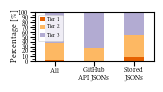

#### [Content Type](03_json2cbor_eval/plots/json-taxonomy-content-type.pdf)

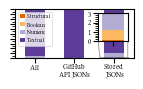

#### [Redundancy](03_json2cbor_eval/plots/json-taxonomy-redundancy.pdf)

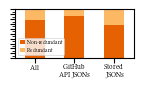

#### [Structure](03_json2cbor_eval/plots/json-taxonomy-structure.pdf)

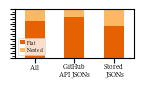

In [7]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_halfcolumn.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.12,
    matplotlib.rcParams["figure.figsize"][1] * 0.75,
)
matplotlib.rcParams["legend.fontsize"] = 4
matplotlib.rcParams["legend.columnspacing"] = 0.4
matplotlib.rcParams["legend.handletextpad"] = 0.3
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    ["#e66101", "#fdb863", "#b2abd2", "#5e3c99"]
)

INDEX = {0: "All", 1: "GitHub\nAPI JSONs", 2: "Stored\nJSONs"}

df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz", delimiter=";")
#df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_epyc7702.csv.gz", delimiter=";")
#df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_i7-1280p.csv.gz", delimiter=";")

for index, row in df[
    df["json_size_tier"].isna() & df["json_content_type"].isna() & df["json_redundancy"].isna() & df["json_structure"].isna()
].iterrows():
    fname = row["json_filename"]
    with open(JSON2CBOR_EVAL_DIR / "jsons" / fname) as f:
        obj = json.load(f)
    tax = taxonomy.main(obj)
    tax[0] = int(tax[0].split()[1])
    tax[1:] = [t.title() if t != "non-redundant" else "Non-redundant" for t in tax[1:]]
    df.loc[index, ["json_size_tier", "json_content_type", "json_redundancy", "json_structure"]] = tax

filepath = OUTPUT_PATH / "json-taxonomy-tier.pdf"
IPython.display.display(IPython.display.Markdown(f"#### [Size Tier]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
category = "json_size_tier"
ax = pandas.concat(
    [
        (df.groupby([category]).size().to_frame() / df[category].shape[0]).T,
        (df[df["github_type"] != "stored_json"].groupby([category]).size().to_frame() / df[df["github_type"] != "stored_json"][category].shape[0]).T,
        (df[df["github_type"] == "stored_json"].groupby([category]).size().to_frame() / df[df["github_type"] == "stored_json"][category].shape[0]).T,
    ],
    ignore_index=True
).rename(index=INDEX).plot.bar(stacked=True, legend=False, rot=0)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1, symbol=""))
ax.set_ylim((0, 1))
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
ax.set_ylabel(r"Percentage [\%]")
_, labels = ax.get_legend_handles_labels()
ax.legend(
    loc="upper left",
    labels=[f"Tier {int(float(t)):d}" for t in labels],
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

filepath = OUTPUT_PATH / "json-taxonomy-content-type.pdf"
IPython.display.display(IPython.display.Markdown(f"#### [Content Type]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
category = "json_content_type"
content_type = pandas.concat(
    [
        (df.groupby([category]).size().to_frame() / df[category].shape[0]).T,
        (df[df["github_type"] != "stored_json"].groupby([category]).size().to_frame() / df[df["github_type"] != "stored_json"][category].shape[0]).T,
        (df[df["github_type"] == "stored_json"].groupby([category]).size().to_frame() / df[df["github_type"] == "stored_json"][category].shape[0]).T,
    ],
    ignore_index=True
).reindex(["Structural", "Boolean", "Numeric", "Textual"], axis=1).rename(index=INDEX)
ax = content_type.plot.bar(stacked=True, legend=False, rot=0)
axi = ax.inset_axes([0.7, 0.35, 0.25, 0.57])
content_type.plot.bar(ax=axi, stacked=True, legend=False, rot=0)
axi.set_xlim((1.65, 2.35))
axi.set_xticklabels([])
axi.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1, symbol="", decimals=0))
axi.set_ylim((0, 0.03))
axi.set_yticks(numpy.arange(0, 0.04, 0.01))
axi.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.002))

ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1, symbol=""))
ax.set_ylim((0, 1))
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
ax.set_yticklabels([])
ax.legend(loc="upper left")
ax.indicate_inset_zoom(axi, edgecolor="black")
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

filepath = OUTPUT_PATH / "json-taxonomy-redundancy.pdf"
IPython.display.display(IPython.display.Markdown(f"#### [Redundancy]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
category = "json_redundancy"
ax = pandas.concat(
    [
        (df.groupby([category]).size().to_frame() / df[category].shape[0]).T,
        (df[df["github_type"] != "stored_json"].groupby([category]).size().to_frame() / df[df["github_type"] != "stored_json"][category].shape[0]).T,
        (df[df["github_type"] == "stored_json"].groupby([category]).size().to_frame() / df[df["github_type"] == "stored_json"][category].shape[0]).T,
    ],
    ignore_index=True
).rename(index=INDEX).plot.bar(stacked=True, legend=False, rot=0)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1, symbol=""))
ax.set_ylim((0, 1))
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.set_yticklabels([])
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
ax.legend(
    loc="lower left",
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

filepath = OUTPUT_PATH / "json-taxonomy-structure.pdf"
IPython.display.display(IPython.display.Markdown(f"#### [Structure]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
category = "json_structure"
ax = pandas.concat(
    [
        (df.groupby([category]).size().to_frame() / df[category].shape[0]).T,
        (df[df["github_type"] != "stored_json"].groupby([category]).size().to_frame() / df[df["github_type"] != "stored_json"][category].shape[0]).T,
        (df[df["github_type"] == "stored_json"].groupby([category]).size().to_frame() / df[df["github_type"] == "stored_json"][category].shape[0]).T,
    ],
    ignore_index=True
).rename(index=INDEX).plot.bar(stacked=True, legend=False, rot=0)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1, symbol=""))
ax.set_ylim((0, 1))
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.set_yticklabels([])
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
ax.legend(
    loc="lower left",
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

### Taxonomy Determination Problems

For some JSON files, the JavaScript-based tool by Viotti and Kinderkhedia was not able to read the file.
In our [analysis above](#Plot-Taxonomy), we use our own, adapted tool to fill out these gaps (ll. 20-29).
Nevertheless, we analyse the reasons why the original tool errored and by how much certain users caused these errors below.

In [8]:
df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz", delimiter=";")
df["user"] = df["json_filename"].swifter.apply(lambda x: pathlib.Path(x).parents[-3].name)

def nan_or_infinity(v):
    if isinstance(v, float) and numpy.isnan(v):
        return True
    return [float("inf"), float("-inf")]


def contains_nan_or_infinity(d):
    for key, value in d.items():
        if isinstance(value, list):
            return any(nan_or_infinity(v) for v in value)
        if isinstance(value, dict):
            return contains_nan_or_infinity(value)
        if nan_or_infinity(key) or nan_or_infinity(value):
            return True
    
taxonomy_problems = []
for _, row in df[df["json_size_tier"].isna()][["user", "json_filename"]].iterrows():
    user, fname = (row["user"], row["json_filename"])
    with open(JSON2CBOR_EVAL_DIR / "jsons" / fname) as f:
        obj = json.load(f)
    tax = tuple(taxonomy.main(obj))
    if isinstance(obj, dict):
        taxonomy_problems.append((user, fname, "dict contains Infinity or NaN" if contains_nan_or_infinity(obj) else "Other problem with dict") + tax)
    elif isinstance(obj, list):
        taxonomy_problems.append((user, fname, "list contains Infinity or NaN" if any(nan_or_infinity(v) for v in obj) else "Other problem with list") + tax)
    elif obj is None:
        taxonomy_problems.append((user, fname, "flat null") + tax)
    else:
        taxonomy_problems.append((user, fname, f"flat {type(obj).__name__}") + tax)
taxonomy_problems = pandas.DataFrame(taxonomy_problems, columns=["user", "filename", "problem", "tier", "content type", "redundancy", "flat"])
pandas.set_option('display.max_rows', len(taxonomy_problems))
pandas.set_option('display.max_colwidth', 1000)
IPython.display.display(IPython.display.Markdown("#### Reasons"))
IPython.display.display(taxonomy_problems)
pandas.reset_option("display.max_rows")
pandas.reset_option('display.max_colwidth')

IPython.display.display(IPython.display.Markdown("#### Problems Per User"))
user_errors = []
for user in taxonomy_problems["user"].unique():
    user_errors.append(
        (
            user,
            (taxonomy_problems["user"] == user).values.sum(),
            ((taxonomy_problems["user"] == user).values.sum() / (df["user"] == user).values.sum()),
        ),
    )
    
user_errors = pandas.DataFrame(user_errors, columns=["user", "errors", "error_rate"])
pandas.set_option('display.max_rows', len(user_errors))
pandas.set_option('display.max_colwidth', 1000)
IPython.display.display(user_errors.sort_values("error_rate", ascending=False).reset_index(drop=True))
pandas.reset_option("display.max_rows")
pandas.reset_option('display.max_colwidth')

Pandas Apply:   0%|          | 0/287671 [00:00<?, ?it/s]

#### Reasons

,user,filename,problem,tier,content type,redundancy,flat
0,rgcottrell,github/rgcottrell/CarND-Behavioral-Cloning-Project/model.json,flat str,tier 3,textual,non-redundant,flat
1,SimonS,github/SimonS/4clojure-solutions/src/001_nothing_but_truth.clj,flat bool,tier 1,numeric,non-redundant,flat
2,devinus,github/devinus/poison/bench/data/utf-8-unescaped.json,flat str,tier 3,textual,non-redundant,flat
3,devinus,github/devinus/poison/bench/data/utf-8-escaped.json,flat str,tier 3,textual,non-redundant,flat
4,ambethia,github/ambethia/katas/javascript/7-kyu/mumbling/fixtures.js,flat null,tier 1,structural,non-redundant,flat
5,ryantm,github/ryantm/ghc/testsuite/tests/typecheck/should_run/tcrun033.stdout,flat str,tier 1,textual,non-redundant,flat
6,paulsmith,github/paulsmith/challenge.gov-scraper/challenges.json,flat null,tier 1,structural,non-redundant,flat
7,matsuu,github/matsuu/isucon11q/home/isucon/.perl-cpm/work/1629453278.198336/Cpanel-JSON-XS-4.26/t/test_parsing/y_structure_lonely_false.json,flat bool,tier 1,numeric,non-redundant,flat
8,matsuu,github/matsuu/isucon11q/home/isucon/.perl-cpm/work/1629453278.198336/Cpanel-JSON-XS-4.26/t/test_parsing/n_number_NaN.json,list contains Infinity or NaN,tier 1,numeric,non-redundant,flat
9,matsuu,github/matsuu/isucon11q/home/isucon/.perl-cpm/work/1629453278.198336/Cpanel-JSON-XS-4.26/t/test_parsing/y_number_real_pos_overflow.json,list contains Infinity or NaN,tier 1,numeric,non-redundant,flat


#### Problems Per User

,user,errors,error_rate
0,Val,1,1.000000
1,harningt,4,0.444444
2,manuel,1,0.250000
3,scottag99,1,0.250000
4,rgcottrell,1,0.200000
5,awt,1,0.166667
6,arfon,1,0.111111
7,paulsmith,1,0.100000
8,svoop,1,0.100000
9,jlouis,1,0.100000


### Users and Taxonomy

Below we analysed if there is a certain correlation between users and taxonomy, i.e., if certain taxonomies gather at certain users. Our analysis shows that there is no distinct correlation.

Pandas Apply:   0%|          | 0/123306 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/123306 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/123306 [00:00<?, ?it/s]

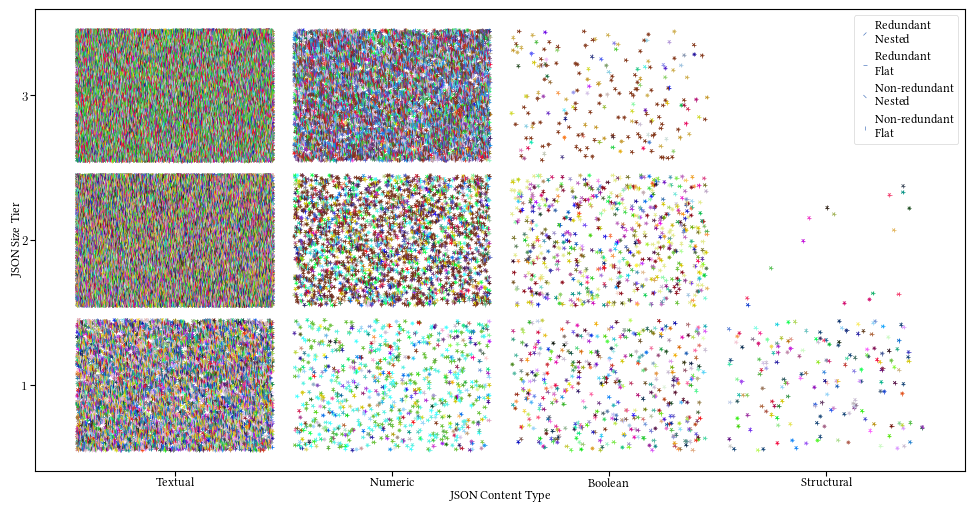

In [9]:
matplotlib.rcParams["figure.figsize"] = (12, 6)
matplotlib.rcParams["legend.fontsize"] = "medium"
matplotlib.rcParams["axes.labelsize"] = "medium"
matplotlib.rcParams["xtick.labelsize"] = "medium"
matplotlib.rcParams["ytick.labelsize"] = "medium"

CTS = ["Textual", "Numeric", "Boolean", "Structural"]
MARKER = {
    ("Redundant", "Nested"): matplotlib.markers.MarkerStyle("_", transform=matplotlib.transforms.Affine2D().rotate_deg(45)),
    ("Non-redundant", "Nested"): matplotlib.markers.MarkerStyle("_", transform=matplotlib.transforms.Affine2D().rotate_deg(135)),
    ("Redundant", "Flat"): matplotlib.markers.MarkerStyle("_", transform=matplotlib.transforms.Affine2D().rotate_deg(0)),
    ("Non-redundant", "Flat"): matplotlib.markers.MarkerStyle("_", transform=matplotlib.transforms.Affine2D().rotate_deg(90)),
}

df = pandas.DataFrame(df[df["user"] != "github"])
users = {k: v for v, k in enumerate(sorted(df["user"].unique(), key=lambda x: x.lower()))}

def sorted_name_to_color(name):
    rgb = int(users[name] * (0xffffff / len(users)))
    return f"#{int(rgb):06x}"

df["user_color"] = df["user"].swifter.apply(lambda x: f"{sorted_name_to_color(x)}")
df["json_content_type_val"] = df["json_content_type"].swifter.apply(lambda x: x if isinstance(x, float) and numpy.isnan(x) else float(CTS.index(x)) + numpy.random.uniform(-0.45, 0.45))
df["json_size_tier_val"] = df["json_size_tier"].swifter.apply(lambda x: x if numpy.isnan(x) else float(x) + numpy.random.uniform(-0.45, 0.45))

for red in ["Redundant", "Non-redundant"]:
    for struct in ["Nested", "Flat"]:
        matplotlib.pyplot.scatter(df["json_content_type_val"], df["json_size_tier_val"], c=df["user_color"], marker=MARKER[red, struct], label=f"{red}\n{struct}")
matplotlib.pyplot.legend(loc="upper right")
matplotlib.pyplot.xlabel("JSON Content Type")
matplotlib.pyplot.xticks(range(len(CTS)), CTS)
matplotlib.pyplot.ylabel("JSON Size Tier")
matplotlib.pyplot.yticks(range(1, 4))
matplotlib.pyplot.show()

user_html = []
for user, color in sorted(df.groupby(["user", "user_color"]).count().index, key=lambda x: x[0].lower()):
    user_html.append(f'<span style="color:{color}">{user} ({color})</span>')
IPython.display.display(IPython.display.HTML(", ".join(user_html)))

## Filenames

Here, we generate the analysis of filenames in our dataset. This results in Figure 5 in our paper.

In [10]:
df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz", delimiter=";")
#df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_epyc7702.csv.gz", delimiter=";")
#df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_i7-1280p.csv.gz", delimiter=";")

def grayout(color, amount):
    c = matplotlib.colors.rgb_to_hsv(color)
    return matplotlib.colors.hsv_to_rgb((c[0], c[1], amount * (c[2])))
    
COLORMAP = [
    "#{:02x}{:02x}{:02x}".format(
        *tuple(int(i * 255) for i in grayout(c, 0.75))
    )
    for c in matplotlib.colormaps["Paired"].colors
]
STATIC_COLORMAP = {
    "package.json": "#a6cee3",
    "package-lock.json": "#1f78b4",
    "Contents.json": "#b2df8a",
    "http-response.json": "#33a02c",
    "bower.json": "#fb9a99",
    "manifest.json": "#e31a1c",
    "metadata.json": "#fdbf6f",
    "settings.json": "#ff7f00",
    "info.json": "#cab2d6",
    "composer.json": "#6a3d9a",
    "hawk-post.json": "#ffff99",
    "config.json": "#b15928",
}
OTHERS_COLOR = "#999999"

def color_func(word, *args, **kwargs):
    if word in STATIC_COLORMAP:
        return STATIC_COLORMAP[word]
    chash = hash(word)
    clen = len(COLORMAP)
    return OTHERS_COLOR

matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullwidth.mplstyle")

matplotlib.rcParams["figure.figsize"] = ((matplotlib.rcParams["figure.figsize"][0] * 9) / 10, (matplotlib.rcParams["figure.figsize"][0] * 2) / 10)
df = df[df["github_type"] == "stored_json"]

names = df["json_filename"].swifter.apply(lambda x: pathlib.Path(x).name).to_frame()
# https://stackoverflow.com/a/52164689
name_frequencies = names["json_filename"].value_counts()
condition = name_frequencies < 2
mask_obs = name_frequencies[condition].index
mask_dict = dict.fromkeys(mask_obs, "Unique names")
names = names.replace(mask_dict)

names = names["json_filename"].value_counts().to_frame().join(
    (names["json_filename"].value_counts().to_frame() * 100 / names["json_filename"].shape[0]).rename(columns={"count": "percentage"}),
)
names["Filename"] = names.index
names = names[["Filename"] + [c for c in names.columns if c != "Filename"]]
names.columns = [c.title() for c in names.columns]
print(names[names["Percentage"] >= 0.5].to_latex(float_format=lambda x: rf"{x:0.1f}\%", index=False))
pandas.options.display.float_format = '{:.3g}%'.format
names[["Count", "Percentage"]]

Pandas Apply:   0%|          | 0/123306 [00:00<?, ?it/s]

\begin{tabular}{lrr}
\toprule
Filename & Count & Percentage \\
\midrule
Unique names & 48498 & 39.3\% \\
package.json & 19484 & 15.8\% \\
package-lock.json & 3723 & 3.0\% \\
Contents.json & 3712 & 3.0\% \\
http-response.json & 1657 & 1.3\% \\
bower.json & 1266 & 1.0\% \\
manifest.json & 1210 & 1.0\% \\
metadata.json & 1206 & 1.0\% \\
settings.json & 1177 & 1.0\% \\
info.json & 1089 & 0.9\% \\
composer.json & 760 & 0.6\% \\
hawk-post.json & 723 & 0.6\% \\
config.json & 695 & 0.6\% \\
\bottomrule
\end{tabular}



,Count,Percentage
json_filename,,
Unique names,48498,39.3%
package.json,19484,15.8%
package-lock.json,3723,3.02%
Contents.json,3712,3.01%
http-response.json,1657,1.34%
...,...,...
templates-2.0.json,2,0.00162%
recording.har,2,0.00162%
push-config-change.json,2,0.00162%


### Plot bar chart

This requires the cell above to be executed beforehand.

Pandas Apply:   0%|          | 0/14 [00:00<?, ?it/s]

#### [Percentage of Common JSON File Names](03_json2cbor_eval/plots/json-names-percentage.pdf)

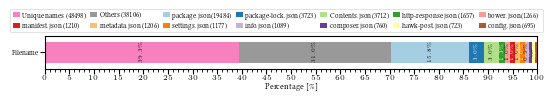

In [11]:
THRESHOLD = 0.5

matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullwidth.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.16,
    matplotlib.rcParams["figure.figsize"][1] * 0.25
)
matplotlib.rcParams["legend.fontsize"] = "xx-small"
matplotlib.rcParams["legend.columnspacing"] = 0.4
matplotlib.rcParams["legend.handletextpad"] = 0.3
colors = {k: v for k, v in STATIC_COLORMAP.items()}
colors["Others"] = OTHERS_COLOR
colors["Unique names"] = "#f781bf"
if "Others" in names.index:
    names = names.drop(index=["Others"])
names.loc["Others", ["Filename", "Count"]] = ("Others", int(names["Count"].sum()) - int(names[names["Percentage"] >= THRESHOLD]["Count"].sum()))
names.loc["Others", "Percentage"] = names["Percentage"].sum() - int(names[names["Percentage"] >= THRESHOLD]["Percentage"].sum())
names["Count"] = pandas.to_numeric(names["Count"], downcast="integer")
percs = names[names["Percentage"] >= THRESHOLD][["Percentage"]].sort_values(["Percentage"], ascending=False)
ax = percs.T.plot.barh(stacked=True, color=colors, legend=False, width=0.9)
matplotlib.pyplot.xlabel(r"Percentage [\%]")
matplotlib.pyplot.xticks(range(0, 110, 5))
matplotlib.pyplot.xlim((0, 100))
matplotlib.pyplot.yticks([0], [r"Filename"])
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
offset = 0
flipflop = -0.1
for i in range(percs.shape[0]):
    perc = float(percs.iloc[i])
    if perc:
        matplotlib.pyplot.text(
            (perc / 2) + offset,
            0, #flipflop if perc < 1 else 0,
            rf"${perc:.1f}\%$",
            ha="center",
            va="center",
            fontsize=4 if perc >= 3 else (4 if perc >= 0.8 else 2),
            rotation=90,
            color="white" if i > 1 and (i % 2) == 1 else "black",
        )
    offset += perc
    flipflop = -flipflop


def flip(items, ncol):
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])

handles, _ = ax.get_legend_handles_labels()
matplotlib.pyplot.legend(
    loc="lower center",
    bbox_to_anchor=(0.47, 1.0),
    ncol=7,
    handles=flip(handles, 7),
    labels=flip(list(
        names[names["Percentage"] >= THRESHOLD].sort_values(["Percentage"], ascending=False).swifter.apply(
            lambda row: f"{row["Filename"]} ({row["Count"]})",
            axis=1
        )
    ), 7)
)
filepath = OUTPUT_PATH / "json-names-percentage.pdf"
IPython.display.display(
    IPython.display.Markdown(
        f"#### [Percentage of Common JSON File Names]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)

## Compression: JSON to CBOR

### Runtime
This covers our evaluation in Section 3.3 “Encoding/Decoding Runtime” and, for `json2cbor_rpi3.csv.gz`, results in the plots shown in Figure 6 and Table 1 of our paper.

#### json2cbor_rpi3.csv.gz

**Iterations**: 100

##### [Encoding](03_json2cbor_eval/plots/json2cbor-times_dumps_rpi3.pdf)

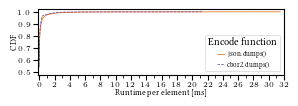

##### [Decoding](03_json2cbor_eval/plots/json2cbor-times_loads_rpi3.pdf)

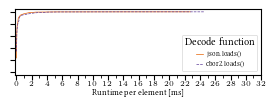

,mean [ms],std. [ms],min. [ms],median [ms],max. [ms]
json.dumps(),0.125,0.629,0.000475,0.00871,31.5
cbor2.dumps(),0.0895,0.435,0.000556,0.00724,21.2
json.loads(),0.0736,0.329,0.000208,0.00609,22.8
cbor2.loads(),0.105,0.475,0.000458,0.00439,24.6


\begin{tabular}{lrrrrr}
\toprule
Function & mean [ms] & std. [ms] & min. [ms] & median [ms] & max. [ms] \\
\midrule
json.dumps() & 0.12 & 0.63 & $4.8 \times 10^{-4}$ & $8.7 \times 10^{-3}$ & 31.5 \\
cbor2.dumps() & 0.09 & 0.44 & $5.6 \times 10^{-4}$ & $7.2 \times 10^{-3}$ & 21.2 \\
json.loads() & 0.07 & 0.33 & $2.1 \times 10^{-4}$ & $6.1 \times 10^{-3}$ & 22.8 \\
cbor2.loads() & 0.11 & 0.47 & $4.6 \times 10^{-4}$ & $4.4 \times 10^{-3}$ & 24.6 \\
\bottomrule
\end{tabular}



#### json2cbor_epyc7702.csv.gz

**Iterations**: 1000

##### [Encoding](03_json2cbor_eval/plots/json2cbor-times_dumps_epyc7702.pdf)

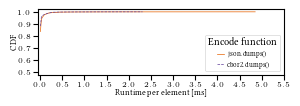

##### [Decoding](03_json2cbor_eval/plots/json2cbor-times_loads_epyc7702.pdf)

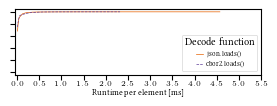

,mean [ms],std. [ms],min. [ms],median [ms],max. [ms]
json.dumps(),0.0125,0.0705,3.82e-05,0.00093,4.86
cbor2.dumps(),0.00938,0.0468,7.58e-05,0.000676,2.32
json.loads(),0.011,0.0447,2.33e-05,0.000909,4.58
cbor2.loads(),0.011,0.0511,4.89e-05,0.000497,2.33


\begin{tabular}{lrrrrr}
\toprule
Function & mean [ms] & std. [ms] & min. [ms] & median [ms] & max. [ms] \\
\midrule
json.dumps() & 0.01 & 0.07 & $3.8 \times 10^{-5}$ & $9.3 \times 10^{-4}$ & 4.86 \\
cbor2.dumps() & $9.4 \times 10^{-3}$ & 0.05 & $7.6 \times 10^{-5}$ & $6.8 \times 10^{-4}$ & 2.32 \\
json.loads() & 0.01 & 0.04 & $2.3 \times 10^{-5}$ & $9.1 \times 10^{-4}$ & 4.58 \\
cbor2.loads() & 0.01 & 0.05 & $4.9 \times 10^{-5}$ & $5.0 \times 10^{-4}$ & 2.33 \\
\bottomrule
\end{tabular}



In [12]:
import IPython.display
import matplotlib.pyplot
import pandas
import pathlib
import numpy
import re

for file in [
    "json2cbor_rpi3.csv.gz",
    "json2cbor_epyc7702.csv.gz",
    # "json2cbor_i7-1280p.csv.gz",
]:
    IPython.display.display(IPython.display.Markdown(f"#### {file}"))
    df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / file, delimiter=";")
    match = re.search(r"json2cbor_([^.]+)\.csv\.gz", file)
    platform = match[1]
    IPython.display.display(IPython.display.Markdown(f"**Iterations**: {df['iterations'].min()}"))
        
    matplotlib.pyplot.gcf()
    matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 1.16,
        matplotlib.rcParams["figure.figsize"][1] / 2
    )
    res = pandas.DataFrame(
        {
            "json.dumps()": df["json_dumps_time"] / df["iterations"] / df["json_elements"],
            "cbor2.dumps()": df["cbor_dumps_time"] / df["iterations"] / df["json_elements"],
            "json.loads()": df["json_loads_time"] / df["iterations"] / df["json_elements"],
            "cbor2.loads()": df["cbor_loads_time"] / df["iterations"] / df["json_elements"],
        }
    )
    xmax = numpy.max(
        [
            res["json.dumps()"] * 1000,
            res["cbor2.dumps()"] * 1000,
            res["json.loads()"] * 1000,
            res["cbor2.loads()"] * 1000,
        ]
    )
    xmax = numpy.ceil(xmax) if (numpy.ceil(xmax) - xmax) > 0.25 else numpy.ceil(xmax) + 0.5
    if (xmax / 20) > 0.5:
        xsteps = numpy.round(xmax / 20)
    else:
        xsteps = 0.5
    
    ax = matplotlib.pyplot.gca()
    ax.set_xlabel("Runtime per element [ms]")
    ax.set_ylabel("CDF")
    plot_cdf(
        [ax],
        res["json.dumps()"] * 1000,
        "json.dumps()",
        {"color": "#e66101"},
    )
    plot_cdf(
        [ax],
        res["cbor2.dumps()"] * 1000,
        "cbor2.dumps()",
        {"color": "#5e3c99", "linestyle": "--"},
    )
    ax.set_xlim((0 - (xsteps / 10), xmax))
    ax.set_xticks(numpy.arange(0, xmax + xsteps, xsteps))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
    ax.set_ylim((0.48, 1.02))
    ax.set_yticks(numpy.arange(0.5, 1.02, 0.1))
    ax.legend(title="Encode function", loc="lower right")
    filepath = OUTPUT_PATH / f"json2cbor-times_dumps_{match[1]}.pdf"
    matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
    IPython.display.display(
        IPython.display.Markdown(
            f"##### [Encoding]({str(filepath.relative_to(pathlib.Path.cwd()))})"
        )
    )
    matplotlib.pyplot.show()
    
    ax = matplotlib.pyplot.gca()
    ax.set_xlabel("Runtime per element [ms]")
    ax.set_yticklabels([])
    plot_cdf(
        [ax],
        res["json.loads()"] * 1000,
        "json.loads()",
        {"color": "#e66101"},
    )
    plot_cdf(
        [ax],
        res["cbor2.loads()"] * 1000,
        "cbor2.loads()",
        {"color": "#5e3c99", "linestyle": "--"},
    )
    ax.set_xlim((0 - (xsteps / 10), xmax))
    ax.set_xticks(numpy.arange(0, xmax + xsteps, xsteps))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
    ax.set_ylim((0.48, 1.02))
    ax.set_yticks(numpy.arange(0.5, 1.02, 0.1))
    ax.legend(title="Decode function", loc="lower right")
    filepath = OUTPUT_PATH / f"json2cbor-times_loads_{match[1]}.pdf"
    matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
    IPython.display.display(
        IPython.display.Markdown(
            f"##### [Decoding]({str(filepath.relative_to(pathlib.Path.cwd()))})"
        )
    )
    matplotlib.pyplot.show()
    stats = pandas.DataFrame(
        {
            "mean [ms]": {
                "json.dumps()": res["json.dumps()"].mean(),
                "cbor2.dumps()": res["cbor2.dumps()"].mean(),
                "json.loads()": res["json.loads()"].mean(),
                "cbor2.loads()": res["cbor2.loads()"].mean(),
            },
            "std. [ms]": {
                "json.dumps()": res["json.dumps()"].std(),
                "cbor2.dumps()": res["cbor2.dumps()"].std(),
                "json.loads()": res["json.loads()"].std(),
                "cbor2.loads()": res["cbor2.loads()"].std(),
            },
            "min. [ms]": {
                "json.dumps()": res["json.dumps()"].min(),
                "cbor2.dumps()": res["cbor2.dumps()"].min(),
                "json.loads()": res["json.loads()"].min(),
                "cbor2.loads()": res["cbor2.loads()"].min(),
            },
            "median [ms]": {
                "json.dumps()": res["json.dumps()"].median(),
                "cbor2.dumps()": res["cbor2.dumps()"].median(),
                "json.loads()": res["json.loads()"].median(),
                "cbor2.loads()": res["cbor2.loads()"].median(),
            },
            "max. [ms]": {
                "json.dumps()": res["json.dumps()"].max(),
                "cbor2.dumps()": res["cbor2.dumps()"].max(),
                "json.loads()": res["json.loads()"].max(),
                "cbor2.loads()": res["cbor2.loads()"].max(),
            },
        }
    )
    stats["Function"] = stats.index
    stats = stats[["Function"] + [c for c in stats.columns if c != "Function"]]
    stats[["mean [ms]", "std. [ms]", "min. [ms]", "median [ms]", "max. [ms]"]] = stats[
        ["mean [ms]", "std. [ms]", "min. [ms]", "median [ms]", "max. [ms]"]
    ] * 1000
    pandas.options.display.float_format = '{:.3g}'.format
    IPython.display.display(stats[["mean [ms]", "std. [ms]", "min. [ms]", "median [ms]", "max. [ms]"]])
    print(
        stats.to_latex(
            float_format=lambda x: re.sub(
                r"(\d+.\d+)e([+-])0*([1-9]\d*)", r"$\1 \\times 10^{\2\3}$",
                f"{x:.1e}" if x < 0.01 else (f"{x:.1f}" if x > 10 else f"{x:.2f}")
            ),
            index=False
        )
    )

### Compression

This contains our analysis for section 3.4 “Compression Gain and Byte Savings” of our paper.

#### Gain

This plots gain $g$ with “Minified JSON size” being the size of the JSON object after removal of structural whitespaces in bytes and “CBOR size” being the size of the CBOR object in bytes.

\$g = \frac{\text{Minified JSON size} - \text{CBOR size}}{\text{Minified JSON size}}\$

##### All sizes (287671)

###### **All content types (287671)**

###### Both redundancies (287671)

###### *Both structures (287671)*

###### [`json2cbor-gain.pdf`](03_json2cbor_eval/plots/json2cbor-gain.pdf)

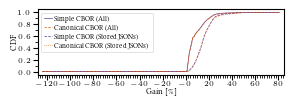

,size [#],mean [%],std. [%],min. [%],median [%],max. [%]
GZipped JSON (All),287671,46.9,45.2,-3000.0,49.0,99.6
Simple CBOR (All),287671,8.5,8.0,-125.0,5.2,81.8
Canonical CBOR (All),287671,8.8,8.3,-125.0,5.3,81.8
GZipped JSON (Stored JSONs),123306,38.6,60.5,-3000.0,46.8,99.6
Simple CBOR (Stored JSONs),123306,15.3,8.1,-125.0,14.4,81.8
Canonical CBOR (Stored JSONs),123306,15.8,8.4,-125.0,14.6,81.8


###### [`json2cbor-blobs-gain.pdf`](03_json2cbor_eval/plots/json2cbor-blobs-gain.pdf)

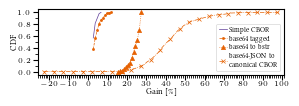

,size [#],mean [%],std. [%],min. [%],median [%],max. [%]
GZipped JSON,123306,43.8,22.7,0.7,41.0,99.2
Simple CBOR,123306,2.8,1.1,1.6,2.4,7.5
base64 tagged,123306,3.9,2.2,1.6,3.2,12.2
base64 to bstr,123306,24.6,2.7,14.4,25.4,27.4
base64-JSON to canonical CBOR,123306,42.0,12.0,-23.8,40.8,98.8


In [13]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based on taxonomy

TIER_READABLE = [
    r"All sizes",
    r"Size tier 1 ($<$100 bytes)",
    r"Size tier 2 ($<$1000 bytes)",
    r"Size tier 3 ($\geq$1000 bytes)",
]

if SLIDE_VERSION:
    matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullslide.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 1.16,
        matplotlib.rcParams["figure.figsize"][1] * 0.8,
    )
    matplotlib.use("pgf")
    matplotlib.rcParams["legend.labelspacing"] = 0.3
else:
    matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 1.16,
        matplotlib.rcParams["figure.figsize"][1] / 2
    )
    matplotlib.use("inline")

base_df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz", delimiter=";")
#base_df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_epyc7702.csv.gz", delimiter=";")
#base_df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_i7-1280p.csv.gz", delimiter=";")
for size_tier in range(len(TIER_READABLE)):
    if size_tier == 0:
        size_df = base_df
        tier_f = ""
    else:
        size_df = base_df[base_df["json_size_tier"] == size_tier]
        tier_f = f"-t{size_tier}"
    if size_df.empty:
        continue
    IPython.display.display(IPython.display.Markdown(f"##### {TIER_READABLE[size_tier]} ({size_df.shape[0]})"))
    for ctype in ["All", "Textual", "Numeric", "Boolean", "Structural"]:
        if ctype == "All":
            type_df = size_df
            ctype = "All content types"
            type_f = ""
        else:
            type_df = size_df[size_df["json_content_type"] == ctype]
            type_f = f"-{ctype.lower()}"
        if type_df.empty:
            continue
        
        IPython.display.display(IPython.display.Markdown(f"###### **{ctype} ({type_df.shape[0]})**"))
        for red in ["Both", "Redundant", "Non-redundant"]:
            if red == "Both":
                red = "Both redundancies"
                red_df = type_df
                red_f = ""
            else:
                red_df = type_df[type_df["json_redundancy"] == red]
                red_f = f"-{red.lower()}"
            if red_df.empty:
                continue
            
            IPython.display.display(IPython.display.Markdown(f"###### {red} ({red_df.shape[0]})"))
            for struct in ["Both", "Flat", "Nested"]:
                if struct == "Both":
                    struct = "Both structures"
                    df = red_df
                    struct_f = ""
                else:
                    df = red_df[red_df["json_structure"] == struct]
                    struct_f = f"-{struct.lower()}"
                if df.empty:
                    continue
                IPython.display.display(IPython.display.Markdown(f"###### *{struct} ({df.shape[0]})*"))
                matplotlib.pyplot.clf()
                ax = matplotlib.pyplot.gca()
                ax.set_xlabel(r"Gain [\%]")
                ax.set_ylabel("CDF")
                ax.set_xlim((-1.28, 0.85))
                ax.set_xticks(numpy.arange(-1.2, 0.9, 0.2))
                ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.02))
                ax.set_ylim((-0.05, 1.05))
                ax.set_yticks(numpy.arange(0, 1.2, 0.2))
                ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
                ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"))
                plot_cdf(
                    [ax],
                    (1 - (df["cbor_simple_size"] / df["json_size"])),
                    "Simple CBOR (All)",
                    {"color": "#5e3c99"},
                )
                plot_cdf(
                    [ax],
                    (1 - (df["cbor_canon_size"] / df["json_size"])),
                    "Canonical CBOR (All)",
                    {"color": "#e66101", "linestyle": "--"},
                )
                wo_github = df[df["github_type"] == "stored_json"]
                plot_cdf(
                    [ax],
                    (1 - (wo_github["cbor_simple_size"] / wo_github["json_size"])),
                    "Simple CBOR (Stored JSONs)",
                    {"color": "#5e3c99", "linestyle": "--"},
                )
                plot_cdf(
                    [ax],
                    (1 - (wo_github["cbor_canon_size"] / wo_github["json_size"])),
                    "Canonical CBOR (Stored JSONs)",
                    {"color": "#e66101", "linestyle": ":"},
                )
                ax.legend(loc="upper left")
                filename = f"json2cbor-gain{tier_f}{type_f}{red_f}{struct_f}.pdf"
                matplotlib.pyplot.savefig(
                    OUTPUT_PATH / filename,
                    bbox_inches="tight",
                    pad_inches=0.01,
                )
                IPython.display.display(
                    IPython.display.Markdown(
                        f"###### [`{filename}`]({OUTPUT_PATH.relative_to(pathlib.Path.cwd()) / filename})"
                    )
                )
                matplotlib.pyplot.show()
                
                stats = pandas.DataFrame(
                    {
                        "size [#]": {
                            "GZipped JSON (All)": df.shape[0],
                            "Simple CBOR (All)": df.shape[0],
                            "Canonical CBOR (All)": df.shape[0],
                            "GZipped JSON (Stored JSONs)": wo_github.shape[0],
                            "Simple CBOR (Stored JSONs)": wo_github.shape[0],
                            "Canonical CBOR (Stored JSONs)": wo_github.shape[0],
                        },
                        "mean [%]": {
                            "GZipped JSON (All)": (1 - (df["json_gz_size"] / df["json_size"])).mean() * 100,
                            "Simple CBOR (All)": (1 - (df["cbor_simple_size"] / df["json_size"])).mean() * 100,
                            "Canonical CBOR (All)": (1 - (df["cbor_canon_size"] / df["json_size"])).mean() * 100,
                            "GZipped JSON (Stored JSONs)": (1 - (wo_github["json_gz_size"] / wo_github["json_size"])).mean() * 100,
                            "Simple CBOR (Stored JSONs)": (1 - (wo_github["cbor_simple_size"] / wo_github["json_size"])).mean() * 100,
                            "Canonical CBOR (Stored JSONs)": (1 - (wo_github["cbor_canon_size"] / wo_github["json_size"])).mean() * 100,
                        },
                        "std. [%]": {
                            "GZipped JSON (All)": (1 - (df["json_gz_size"] / df["json_size"])).std() * 100,
                            "Simple CBOR (All)": (1 - (df["cbor_simple_size"] / df["json_size"])).std() * 100,
                            "Canonical CBOR (All)": (1 - (df["cbor_canon_size"] / df["json_size"])).std() * 100,
                            "GZipped JSON (Stored JSONs)": (1 - (wo_github["json_gz_size"] / wo_github["json_size"])).std() * 100,
                            "Simple CBOR (Stored JSONs)": (1 - (wo_github["cbor_simple_size"] / wo_github["json_size"])).std() * 100,
                            "Canonical CBOR (Stored JSONs)": (1 - (wo_github["cbor_canon_size"] / wo_github["json_size"])).std() * 100,
                        },
                        "min. [%]": {
                            "GZipped JSON (All)": (1 - (df["json_gz_size"] / df["json_size"])).min() * 100,
                            "Simple CBOR (All)": (1 - (df["cbor_simple_size"] / df["json_size"])).min() * 100,
                            "Canonical CBOR (All)": (1 - (df["cbor_canon_size"] / df["json_size"])).min() * 100,
                            "GZipped JSON (Stored JSONs)": (1 - (wo_github["json_gz_size"] / wo_github["json_size"])).min() * 100,
                            "Simple CBOR (Stored JSONs)": (1 - (wo_github["cbor_simple_size"] / wo_github["json_size"])).min() * 100,
                            "Canonical CBOR (Stored JSONs)": (1 - (wo_github["cbor_canon_size"] / wo_github["json_size"])).min() * 100,
                        },
                        "median [%]": {
                            "GZipped JSON (All)": (1 - (df["json_gz_size"] / df["json_size"])).median() * 100,
                            "Simple CBOR (All)": (1 - (df["cbor_simple_size"] / df["json_size"])).median() * 100,
                            "Canonical CBOR (All)": (1 - (df["cbor_canon_size"] / df["json_size"])).median() * 100,
                            "GZipped JSON (Stored JSONs)": (1 - (wo_github["json_gz_size"] / wo_github["json_size"])).median() * 100,
                            "Simple CBOR (Stored JSONs)": (1 - (wo_github["cbor_simple_size"] / wo_github["json_size"])).median() * 100,
                            "Canonical CBOR (Stored JSONs)": (1 - (wo_github["cbor_canon_size"] / wo_github["json_size"])).median() * 100,
                        },
                        "max. [%]": {
                            "GZipped JSON (All)": (1 - (df["json_gz_size"] / df["json_size"])).max() * 100,
                            "Simple CBOR (All)": (1 - (df["cbor_simple_size"] / df["json_size"])).max() * 100,
                            "Canonical CBOR (All)": (1 - (df["cbor_canon_size"] / df["json_size"])).max() * 100,
                            "GZipped JSON (Stored JSONs)": (1 - (wo_github["json_gz_size"] / wo_github["json_size"])).max() * 100,
                            "Simple CBOR (Stored JSONs)": (1 - (wo_github["cbor_simple_size"] / wo_github["json_size"])).max() * 100,
                            "Canonical CBOR (Stored JSONs)": (1 - (wo_github["cbor_canon_size"] / wo_github["json_size"])).max() * 100,
                        },
                    }
                )
                pandas.options.display.float_format = '{:.1f}'.format
                IPython.display.display(stats)

                # ====================
                # GitHub Blob Analysis
                # ====================
                
                filter = ~df["cbor_base64_cbor_size"].isna()
                filtered_df = df[filter]
            
                if filtered_df.empty:
                    IPython.display.display(IPython.display.HTML('<span style="color: red;">No blobs in this taxonomy</span>'))
                    continue
                
                matplotlib.pyplot.clf()
                ax = matplotlib.pyplot.gca()
                ax.set_xlabel(r"Gain [\%]")
                ax.set_ylabel("CDF")
                ax.set_xlim((-0.26, 1.01))
                ax.set_xticks(numpy.arange(-0.20, 1.05, 0.10))
                ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.01))
                ax.set_ylim((-0.05, 1.05))
                ax.set_yticks(numpy.arange(0, 1.2, 0.2))
                ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
                ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:0.0f}$"))
                plot_cdf(
                    [ax],
                    (1 - (filtered_df["cbor_simple_size"] / filtered_df["json_size"])),
                    "Simple CBOR",
                    {"color": "#5e3c99"},
                )
                plot_cdf(
                    [ax],
                    (1 - (filtered_df["cbor_base64_tagged_size"] / filtered_df["json_size"])),
                    "base64 tagged",
                    {"color": "#e66101", "linestyle": "--", "marker": "."},
                )
                plot_cdf(
                    [ax],
                    (1 - (filtered_df["cbor_base64_bin_size"] / filtered_df["json_size"])),
                    "base64 to bstr",
                    {"color": "#e66101", "linestyle": ":", "marker": "^"},
                )
        
        
                plot_cdf(
                    [ax],
                    (1 - (filtered_df["cbor_base64_cbor_size"] / filtered_df["json_size"])),
                    "base64-JSON to\ncanonical CBOR",
                    {"color": "#e66101", "linestyle": "-.", "marker": "x", "markevery": 5},
                )
                filename = f"json2cbor-blobs-gain{tier_f}{type_f}{red_f}{struct_f}.pdf"
                ax.legend(loc="lower right")
                matplotlib.pyplot.savefig(
                    OUTPUT_PATH / filename,
                    bbox_inches="tight",
                    pad_inches=0.01,
                )
                IPython.display.display(
                    IPython.display.Markdown(
                        f"###### [`{filename}`]({OUTPUT_PATH.relative_to(pathlib.Path.cwd()) / filename})"
                    )
                )
                matplotlib.pyplot.show()
                stats = pandas.DataFrame(
                    {
                        "size [#]": {
                            "GZipped JSON": filtered_df.shape[0],
                            "Simple CBOR": filtered_df.shape[0],
                            "base64 tagged": filtered_df.shape[0],
                            "base64 to bstr": filtered_df.shape[0],
                            "base64-JSON to canonical CBOR": filtered_df[~filtered_df["cbor_base64_cbor_size"].isna()].shape[0],
                        },
                        "mean [%]": {
                            "GZipped JSON": (1 - (filtered_df["json_gz_size"] / filtered_df["json_size"])).mean() * 100,
                            "Simple CBOR": (1 - (filtered_df["cbor_simple_size"] / filtered_df["json_size"])).mean() * 100,
                            "base64 tagged": (1 - (filtered_df["cbor_base64_tagged_size"] / filtered_df["json_size"])).mean() * 100,
                            "base64 to bstr": (1 - (filtered_df["cbor_base64_bin_size"] / filtered_df["json_size"])).mean() * 100,
                            "base64-JSON to canonical CBOR": (1 - (filtered_df["cbor_base64_cbor_size"] / filtered_df["json_size"])).mean() * 100,
                        },
                        "std. [%]": {
                            "GZipped JSON": (1 - (filtered_df["json_gz_size"] / filtered_df["json_size"])).std() * 100,
                            "Simple CBOR": (1 - (filtered_df["cbor_simple_size"] / filtered_df["json_size"])).std() * 100,
                            "base64 tagged": (1 - (filtered_df["cbor_base64_tagged_size"] / filtered_df["json_size"])).std() * 100,
                            "base64 to bstr": (1 - (filtered_df["cbor_base64_bin_size"] / filtered_df["json_size"])).std() * 100,
                            "base64-JSON to canonical CBOR": (1 - (filtered_df["cbor_base64_cbor_size"] / filtered_df["json_size"])).std() * 100,
                        },
                        "min. [%]": {
                            "GZipped JSON": (1 - (filtered_df["json_gz_size"] / filtered_df["json_size"])).min() * 100,
                            "Simple CBOR": (1 - (filtered_df["cbor_simple_size"] / filtered_df["json_size"])).min() * 100,
                            "base64 tagged": (1 - (filtered_df["cbor_base64_tagged_size"] / filtered_df["json_size"])).min() * 100,
                            "base64 to bstr": (1 - (filtered_df["cbor_base64_bin_size"] / filtered_df["json_size"])).min() * 100,
                            "base64-JSON to canonical CBOR": (1 - (filtered_df["cbor_base64_cbor_size"] / filtered_df["json_size"])).min() * 100,
                        },
                        "median [%]": {
                            "GZipped JSON": (1 - (filtered_df["json_gz_size"] / filtered_df["json_size"])).median() * 100,
                            "Simple CBOR": (1 - (filtered_df["cbor_simple_size"] / filtered_df["json_size"])).median() * 100,
                            "base64 tagged": (1 - (filtered_df["cbor_base64_tagged_size"] / filtered_df["json_size"])).median() * 100,
                            "base64 to bstr": (1 - (filtered_df["cbor_base64_bin_size"] / filtered_df["json_size"])).median() * 100,
                            "base64-JSON to canonical CBOR": (1 - (filtered_df["cbor_base64_cbor_size"] / filtered_df["json_size"])).median() * 100,
                        },
                        "max. [%]": {
                            "GZipped JSON": (1 - (filtered_df["json_gz_size"] / filtered_df["json_size"])).max() * 100,
                            "Simple CBOR": (1 - (filtered_df["cbor_simple_size"] / filtered_df["json_size"])).max() * 100,
                            "base64 tagged": (1 - (filtered_df["cbor_base64_tagged_size"] / filtered_df["json_size"])).max() * 100,
                            "base64 to bstr": (1 - (filtered_df["cbor_base64_bin_size"] / filtered_df["json_size"])).max() * 100,
                            "base64-JSON to canonical CBOR": (1 - (filtered_df["cbor_base64_cbor_size"] / filtered_df["json_size"])).max() * 100,
                        },
                    }
                )
                pandas.options.display.float_format = '{:.1f}'.format
                IPython.display.display(stats)
                if ONLY_PAPER:
                    break
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

#### Byte Savings

This plots byte savings $b$ with “Minified JSON size” being the size of the JSON object after removal of structural whitespaces in bytes and “CBOR size” being the size of the CBOR object in bytes.

\$b = \text{Minified JSON size} - \text{CBOR size}\$

##### All sizes (287671)

###### **All content types (287671)**

###### Both redundancies (287671)

###### *Both structures (287671)*

###### [`json2cbor-savings.pdf`](03_json2cbor_eval/plots/json2cbor-savings.pdf)

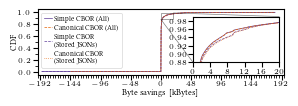

,size [#],mean [bytes],std. [bytes],min. [bytes],median [bytes],max. [bytes]
GZipped JSON (All),287671,20785.9,67420.8,-78,826,641046
Simple CBOR (All),287671,1600.1,6055.2,-194055,84,186117
Canonical CBOR (All),287671,1631.7,6088.4,-146817,85,186117
GZipped JSON (Stored JSONs),123306,9424.2,29984.9,-78,407,348617
Simple CBOR (Stored JSONs),123306,1730.4,6675.3,-194055,101,186117
Canonical CBOR (Stored JSONs),123306,1796.5,6730.5,-146817,104,186117


###### [`json2cbor-blobs-savings.pdf`](03_json2cbor_eval/plots/json2cbor-blobs-savings.pdf)

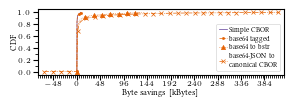

,size [#],mean [bytes],std. [bytes],min. [bytes],median [bytes],max. [bytes]
GZipped JSON,123306,17224.8,57576.7,2,745,480576
Simple CBOR,123306,379.5,1150.2,20,43,7982
base64 tagged,123306,393.5,1150.2,34,57,7996
base64 to bstr,123306,6169.9,19560.0,45,450,135440
base64-JSON to canonical CBOR,123306,12129.0,42328.3,-68000,752,424695


In [14]:
SLIDE_VERSION = False  # set to true for styling for slide set
ONLY_PAPER = True      # set to False to plot with filters based on taxonomy
LABEL_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)

TIER_READABLE = [
    "All sizes",
    "Size tier 1 (<100 bytes)",
    "Size tier 2 (<1000 bytes)",
    "Size tier 3 (≥1000 bytes)",
]
if SLIDE_VERSION:
    matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullslide.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 1.16,
        matplotlib.rcParams["figure.figsize"][1] * 0.8,
    )
    matplotlib.use("pgf")
    matplotlib.rcParams["legend.labelspacing"] = 0.3
else:
    matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 1.16,
        matplotlib.rcParams["figure.figsize"][1] / 2
    )
    matplotlib.use("inline")
    
base_df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz", delimiter=";")
#base_df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_epyc7702.csv.gz", delimiter=";")
#base_df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_i7-1280p.csv.gz", delimiter=";")


def byte_savings(df, cbor_col, unit=None):
    return (df["json_size"] - df[cbor_col])


unit = None


for size_tier in range(len(TIER_READABLE)):
    if size_tier == 0:
        size_df = base_df
        tier_f = ""
    else:
        size_df = base_df[base_df["json_size_tier"] == size_tier]
        tier_f = f"-t{size_tier}"
    if size_df.empty:
        continue
    IPython.display.display(IPython.display.Markdown(f"##### {TIER_READABLE[size_tier]} ({size_df.shape[0]})"))
    for ctype in ["All", "Textual", "Numeric", "Boolean", "Structural"]:
        if ctype == "All":
            type_df = size_df
            ctype = "All content types"
            type_f = ""
        else:
            type_df = size_df[size_df["json_content_type"] == ctype]
            type_f = f"-{ctype.lower()}"
        if type_df.empty:
            continue
        
        IPython.display.display(IPython.display.Markdown(f"###### **{ctype} ({type_df.shape[0]})**"))
        for red in ["Both", "Redundant", "Non-redundant"]:
            if red == "Both":
                red = "Both redundancies"
                red_df = type_df
                red_f = ""
            else:
                red_df = type_df[type_df["json_redundancy"] == red]
                red_f = f"-{red.lower()}"
            if red_df.empty:
                continue
            
            IPython.display.display(IPython.display.Markdown(f"###### {red} ({red_df.shape[0]})"))
            for struct in ["Both", "Flat", "Nested"]:
                if struct == "Both":
                    struct = "Both structures"
                    df = red_df
                    struct_f = ""
                else:
                    df = red_df[red_df["json_structure"] == struct]
                    struct_f = f"-{struct.lower()}"
                if df.empty:
                    continue
                IPython.display.display(IPython.display.Markdown(f"###### *{struct} ({df.shape[0]})*"))
                matplotlib.pyplot.clf()        
                ax = matplotlib.pyplot.gca()
                ax.set_xlabel(f"Byte savings [kBytes]")
                ax.set_xlim((-196 * 1024, 196 * 1024))
                ax.set_xticks(numpy.arange(-192 * 1024, 193 * 1024, 48 * 1024))
                ax.xaxis.set_major_formatter(
                    matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1024:0.0f}$")
                )
                ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(4 * 1024))
                ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
                
                if LABEL_YTICKS:
                    ax.set_ylabel("CDF")
                else:
                    ax.set_yticklabels([])
                ax.set_ylim((-0.05, 1.05))
                ax.set_yticks(numpy.arange(0, 1.2, 0.2))

                axes = [ax]
                if size_tier == 0 and ctype == "All content types" and red == "Both redundancies" and struct == "Both structures":
                    axin = ax.inset_axes([0.63, 0.19, 0.35, 0.70])
                    axin.set_xlim((0, 20 * 1024))
                    axin.set_xticks(numpy.arange(0, 21 * 1024, 4 * 1024))
                    axin.xaxis.set_major_formatter(
                        matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1024:0.0f}$")
                    )
                    axin.set_ylim((0.88, 0.99))
                    axin.set_yticks(numpy.arange(0.88, 1.0, 0.02))
                    ax.indicate_inset_zoom(axin, edgecolor="black")
                    axes.append(axin)
                
                plot_cdf(
                    axes,
                    byte_savings(df, "cbor_simple_size", unit),
                    "Simple CBOR (All)",
                    {"color": "#5e3c99"},
                    bin_size=1,
                )
                plot_cdf(
                    axes,
                    byte_savings(df, "cbor_canon_size", unit),
                    "Canonical CBOR (All)",
                    {"color": "#e66101", "linestyle": "--"},
                    bin_size=1,
                )
                wo_github = df[df["github_type"] == "stored_json"]
                plot_cdf(
                    axes,
                    byte_savings(wo_github, "cbor_simple_size", unit),
                    "Simple CBOR\n(Stored JSONs)",
                    {"color": "#5e3c99", "linestyle": "--"},
                    bin_size=1,
                )
                plot_cdf(
                    axes,
                    byte_savings(wo_github, "cbor_canon_size", unit),
                    "Canonical CBOR\n(Stored JSONs)",
                    {"color": "#e66101", "linestyle": ":"},
                    bin_size=1,
                )        
                ax.legend(loc="upper left")
                filename = f"json2cbor-savings{tier_f}{type_f}{red_f}{struct_f}.pdf"
                matplotlib.pyplot.savefig(
                    OUTPUT_PATH / filename,
                    bbox_inches="tight",
                    pad_inches=0.01,
                )
                IPython.display.display(
                    IPython.display.Markdown(
                        f"###### [`{filename}`]({OUTPUT_PATH.relative_to(pathlib.Path.cwd()) / filename})"
                    )
                )
                matplotlib.pyplot.show()
                
                stats = pandas.DataFrame(
                    {
                        "size [#]": {
                            "GZipped JSON (All)": df.shape[0],
                            "Simple CBOR (All)": df.shape[0],
                            "Canonical CBOR (All)": df.shape[0],
                            "GZipped JSON (Stored JSONs)": wo_github.shape[0],
                            "Simple CBOR (Stored JSONs)": wo_github.shape[0],
                            "Canonical CBOR (Stored JSONs)": wo_github.shape[0],
                        },
                        "mean [bytes]": {
                            "GZipped JSON (All)": byte_savings(df, "json_gz_size", unit).mean(),
                            "Simple CBOR (All)": byte_savings(df, "cbor_simple_size", unit).mean(),
                            "Canonical CBOR (All)": byte_savings(df, "cbor_canon_size", unit).mean(),
                            "GZipped JSON (Stored JSONs)": byte_savings(wo_github, "json_gz_size", unit).mean(),
                            "Simple CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_simple_size", unit).mean(),
                            "Canonical CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_canon_size", unit).mean(),
                        },
                        "std. [bytes]": {
                            "GZipped JSON (All)": byte_savings(df, "json_gz_size", unit).std(),
                            "Simple CBOR (All)": byte_savings(df, "cbor_simple_size", unit).std(),
                            "Canonical CBOR (All)": byte_savings(df, "cbor_canon_size", unit).std(),
                            "GZipped JSON (Stored JSONs)": byte_savings(wo_github, "json_gz_size", unit).std(),
                            "Simple CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_simple_size", unit).std(),
                            "Canonical CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_canon_size", unit).std(),
                        },
                        "min. [bytes]": {
                            "GZipped JSON (All)": byte_savings(df, "json_gz_size", unit).min(),
                            "Simple CBOR (All)": byte_savings(df, "cbor_simple_size", unit).min(),
                            "Canonical CBOR (All)": byte_savings(df, "cbor_canon_size", unit).min(),
                            "GZipped JSON (Stored JSONs)": byte_savings(wo_github, "json_gz_size", unit).min(),
                            "Simple CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_simple_size", unit).min(),
                            "Canonical CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_canon_size", unit).min(),
                        },
                        "median [bytes]": {
                            "GZipped JSON (All)": byte_savings(df, "json_gz_size", unit).median(),
                            "Simple CBOR (All)": byte_savings(df, "cbor_simple_size", unit).median(),
                            "Canonical CBOR (All)": byte_savings(df, "cbor_canon_size", unit).median(),
                            "GZipped JSON (Stored JSONs)": byte_savings(wo_github, "json_gz_size", unit).median(),
                            "Simple CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_simple_size", unit).median(),
                            "Canonical CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_canon_size", unit).median(),
                        },
                        "max. [bytes]": {
                            "GZipped JSON (All)": byte_savings(df, "json_gz_size", unit).max(),
                            "Simple CBOR (All)": byte_savings(df, "cbor_simple_size", unit).max(),
                            "Canonical CBOR (All)": byte_savings(df, "cbor_canon_size", unit).max(),
                            "GZipped JSON (Stored JSONs)": byte_savings(wo_github, "json_gz_size", unit).max(),
                            "Simple CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_simple_size", unit).max(),
                            "Canonical CBOR (Stored JSONs)": byte_savings(wo_github, "cbor_canon_size", unit).max(),
                        },
                    }
                )
                pandas.options.display.float_format = lambda x: f'{x:.0f}' if x == int(x) else f'{x:.1f}'
                IPython.display.display(stats)
                
                matplotlib.pyplot.clf()
                ax = matplotlib.pyplot.gca()
                ax.set_xlabel(f"Byte savings [kBytes]")
                ax.set_xlim((-80 * 1024, 424 * 1024))
                ax.set_xticks(numpy.arange(-48 * 1024, 424 * 1024, 48 * 1024))
                ax.xaxis.set_major_formatter(
                    matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1024:0.0f}$")
                )
                ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
                ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(4 * 1024))
                                
                filter = ~df["cbor_base64_cbor_size"].isna()
                filtered_df = df[filter]
                
                if filtered_df.empty:
                    continue

                if LABEL_YTICKS:
                    ax.set_ylabel("CDF")
                else:
                    ax.set_yticklabels([])
                ax.set_ylim((-0.05, 1.05))
                ax.set_yticks(numpy.arange(0, 1.2, 0.2))
                plot_cdf(
                    [ax],
                    byte_savings(filtered_df, "cbor_simple_size", unit),
                    "Simple CBOR",
                    {"color": "#5e3c99"},
                    bin_size=1,
                )

                plot_cdf(
                    [ax],
                    byte_savings(filtered_df, "cbor_base64_tagged_size", unit),
                    "base64 tagged",
                    {
                        "color": "#e66101",
                        "linestyle": "--",
                        "marker": ".", 
                        "markevery": int(filtered_df.shape[0] / (7.05 * 4.5)),
                    },
                    bin_size=1,
                )
                plot_cdf(
                    [ax],
                    byte_savings(filtered_df, "cbor_base64_bin_size", unit),
                    "base64 to bstr",
                    {
                        "color": "#e66101",
                        "linestyle": ":",
                        "marker": "^",
                        "markevery": int(filtered_df.shape[0] / 7.05),
                    },
                    bin_size=1,
                )
                plot_cdf(
                    [ax],
                    byte_savings(filtered_df, "cbor_base64_cbor_size", unit),
                    "base64-JSON to\ncanonical CBOR",
                    {
                        "color": "#e66101",
                        "linestyle": "-.",
                        "marker": "x",
                        "markevery": int(filtered_df.shape[0] / 7.05)
                    },
                    bin_size=1,
                )
                ax.legend(loc="lower right")
                filename = f"json2cbor-blobs-savings{tier_f}{type_f}{red_f}{struct_f}.pdf"
                matplotlib.pyplot.savefig(
                    OUTPUT_PATH / filename,
                    bbox_inches="tight",
                    pad_inches=0.01,
                )
                IPython.display.display(
                    IPython.display.Markdown(
                        f"###### [`{filename}`]({OUTPUT_PATH.relative_to(pathlib.Path.cwd()) / filename})"
                    )
                )
                matplotlib.pyplot.show()
                stats = pandas.DataFrame(
                    {
                        "size [#]": {
                            "GZipped JSON": filtered_df.shape[0],
                            "Simple CBOR": filtered_df.shape[0],
                            "base64 tagged": filtered_df.shape[0],
                            "base64 to bstr": filtered_df.shape[0],
                            "base64-JSON to canonical CBOR": filtered_df[~filtered_df["cbor_base64_cbor_size"].isna()].shape[0],
                        },
                        "mean [bytes]": {
                            "GZipped JSON": byte_savings(filtered_df, "json_gz_size", unit).mean(),
                            "Simple CBOR": byte_savings(filtered_df, "cbor_simple_size", unit).mean(),
                            "base64 tagged": byte_savings(filtered_df, "cbor_base64_tagged_size", unit).mean(),
                            "base64 to bstr": byte_savings(filtered_df, "cbor_base64_bin_size", unit).mean(),
                            "base64-JSON to canonical CBOR": byte_savings(filtered_df, "cbor_base64_cbor_size", unit).mean(),
                        },
                        "std. [bytes]": {
                            "GZipped JSON": byte_savings(filtered_df, "json_gz_size", unit).std(),
                            "Simple CBOR": byte_savings(filtered_df, "cbor_simple_size", unit).std(),
                            "base64 tagged": byte_savings(filtered_df, "cbor_base64_tagged_size", unit).std(),
                            "base64 to bstr": byte_savings(filtered_df, "cbor_base64_bin_size", unit).std(),
                            "base64-JSON to canonical CBOR": byte_savings(filtered_df, "cbor_base64_cbor_size", unit).std(),
                        },
                        "min. [bytes]": {
                            "GZipped JSON": byte_savings(filtered_df, "json_gz_size", unit).min(),
                            "Simple CBOR": byte_savings(filtered_df, "cbor_simple_size", unit).min(),
                            "base64 tagged": byte_savings(filtered_df, "cbor_base64_tagged_size", unit).min(),
                            "base64 to bstr": byte_savings(filtered_df, "cbor_base64_bin_size", unit).min(),
                            "base64-JSON to canonical CBOR": byte_savings(filtered_df, "cbor_base64_cbor_size", unit).min(),
                        },
                        "median [bytes]": {
                            "GZipped JSON": byte_savings(filtered_df, "json_gz_size", unit).median(),
                            "Simple CBOR": byte_savings(filtered_df, "cbor_simple_size", unit).median(),
                            "base64 tagged": byte_savings(filtered_df, "cbor_base64_tagged_size", unit).median(),
                            "base64 to bstr": byte_savings(filtered_df, "cbor_base64_bin_size", unit).median(),
                            "base64-JSON to canonical CBOR": byte_savings(filtered_df, "cbor_base64_cbor_size", unit).median(),
                        },
                        "max. [bytes]": {
                            "GZipped JSON": byte_savings(filtered_df, "json_gz_size", unit).max(),
                            "Simple CBOR": byte_savings(filtered_df, "cbor_simple_size", unit).max(),
                            "base64 tagged": byte_savings(filtered_df, "cbor_base64_tagged_size", unit).max(),
                            "base64 to bstr": byte_savings(filtered_df, "cbor_base64_bin_size", unit).max(),
                            "base64-JSON to canonical CBOR": byte_savings(filtered_df, "cbor_base64_cbor_size", unit).max(),
                        },
                    }
                )
                pandas.options.display.float_format = lambda x: f'{x:.0f}' if x == int(x) else f'{x:.1f}'
                IPython.display.display(stats)
                if ONLY_PAPER:
                    break
            if ONLY_PAPER:
                break
        if ONLY_PAPER:
            break
    if ONLY_PAPER:
        break

#### Inspect byte saving extremes

Here, we have a look at which JSON file caused the minimum and maximum byte savings, respectively.

In [15]:
df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz", delimiter=";")

min_file = df[byte_savings(df, "cbor_simple_size", unit) == byte_savings(df, "cbor_simple_size").min()].iloc[0].json_filename
max_file = df[byte_savings(df, "cbor_simple_size", unit) == byte_savings(df, "cbor_simple_size").max()].iloc[0].json_filename

IPython.display.display(
    IPython.display.Markdown(
        f"min: [{min_file}]({str((JSON2CBOR_EVAL_DIR / 'jsons' / min_file).relative_to(pathlib.Path.cwd()))})"
    )
)
IPython.display.display(
    IPython.display.Markdown(
        f"max: [{max_file}]({str((JSON2CBOR_EVAL_DIR / 'jsons' / max_file).relative_to(pathlib.Path.cwd()))})"
    )
)

min: [github/vincent/three-arena/gamedata/cubeslam/rabbit.json](03_json2cbor_eval/jsons/github/vincent/three-arena/gamedata/cubeslam/rabbit.json)

max: [github/niryariv/israel_gushim/haaravahatihona.topojson](03_json2cbor_eval/jsons/github/niryariv/israel_gushim/haaravahatihona.topojson)